Paquetes necesarios

In [3]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

Tarea 1

Obtener imagen en escala de grises

(512, 512)


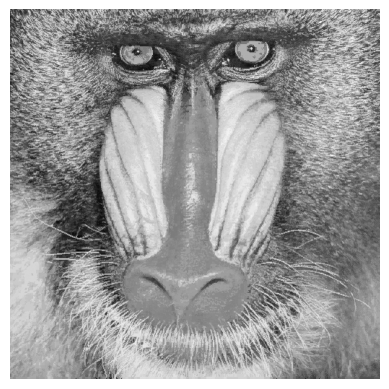

In [4]:
#Obtener imagen
img = cv2.imread('mandril.jpg')

#Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gris.shape)
#Muestra, indicando el mapa de color de grises con matplotlib
plt.figure()
#Eliminamos etiquetas de los ejes
plt.axis("off")
#Muestra la imagen en grises
plt.imshow(gris, cmap='gray') 
plt.show()

Obtener contornos con Canny

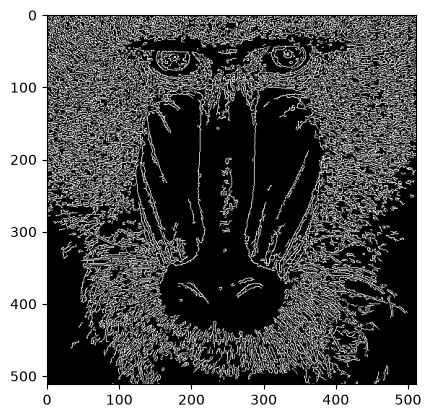

In [5]:
#Obtiene contornos con el operador de Canny
#Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 100, 200) #prueba a jugar con umbrales (entre 0 y 255)
#print(canny) #Muestra contenido, valores 0 o 255
#Visualiza resultado
plt.imshow(canny, cmap='gray') 
plt.show()

Conteo de píxeles blancos por filas

Valor máximo (maxfil): 0.4297
Umbral (0.90 * maxfil): 0.3867
Número de filas que cumplen la condición: 7
Posiciones de dichas filas: [  6  12  15  20  21  88 100]


(0.0, 512.0)

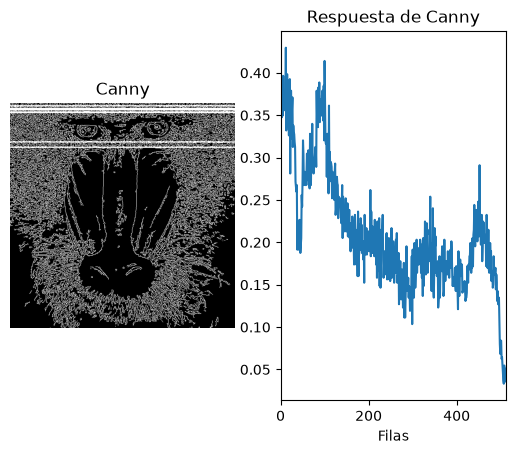

In [6]:
#Cuenta el número de píxeles blancos (255) por fila
#Suma los valores de los pixeles por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de columnas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por fila
rows = row_counts[:, 0] / (255 * canny.shape[1])

maxfil = np.max(rows)
umbral = 0.9 * maxfil

max_rows = np.where(rows >= umbral)[0]

print(f"Valor máximo (maxfil): {maxfil:.4f}")
print(f"Umbral (0.90 * maxfil): {umbral:.4f}")
print(f"Número de filas que cumplen la condición: {len(max_rows)}")
print(f"Posiciones de dichas filas: {max_rows}")

# Define tipografías (Bastante limitadas en OpenCV)
font = cv2.FONT_HERSHEY_SIMPLEX

# Añadir líneas que resalten el umbral


for row in max_rows:
    cv2.line(canny, (0, row), (canny.shape[1] - 1, row), 255, 2)

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)
#Rango en x definido por las filas
plt.xlim([0, canny.shape[1]])

Tarea 2

Obtener imagen con Sobel en 8 bits

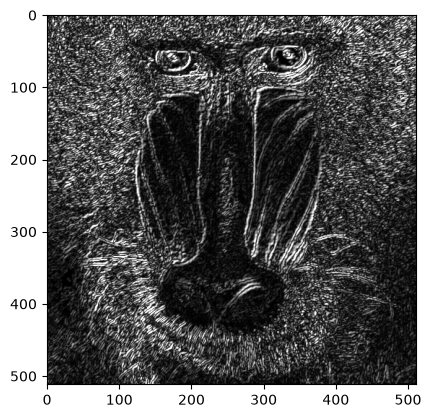

In [14]:
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

sobel8 = cv2.convertScaleAbs(sobel)

plt.imshow(sobel8, cmap='gray')

Se aplica el umbral a la imagen

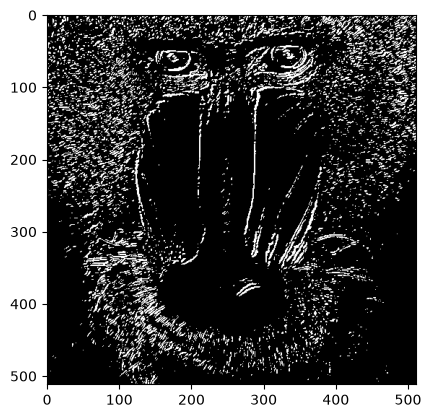

In [20]:
#Define valor umbral
valorUmbral = 130 #Prueba otros valores
#Obtiene imagen umbralizada para dicho valor definido
_, sobel8Umbral = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)
#Muestra resultado
plt.imshow(sobel8Umbral, cmap='gray')
plt.show()

Ahora se realiza el conteo tanto por filas y columnas y se muestra la estadística

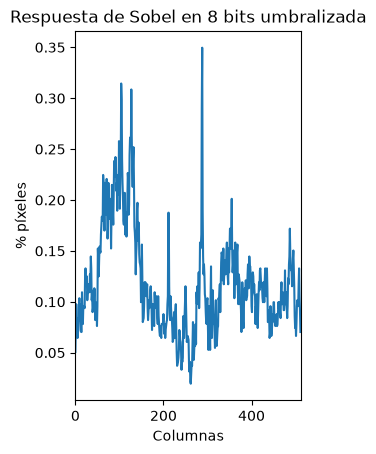

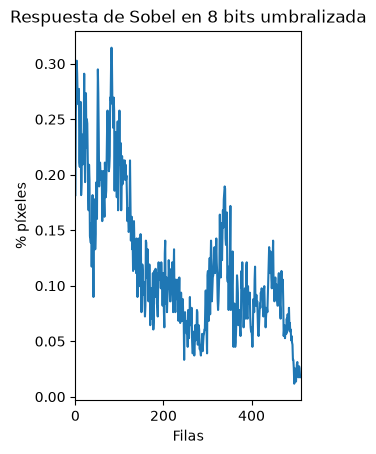

In [26]:
# Columnas

col_counts = cv2.reduce(sobel8Umbral, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

sobel_cols = col_counts[0] / (255 * sobel8Umbral.shape[0])

plt.subplot(1, 2, 2)
plt.title("Respuesta de Sobel en 8 bits umbralizada")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(sobel_cols)
plt.xlim([0, canny.shape[1]])
plt.show()

# Filas

row_counts = cv2.reduce(sobel8Umbral, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

sobel_rows = row_counts[:, 0] / (255 * sobel8Umbral.shape[1])

plt.subplot(1, 2, 2)
plt.title("Respuesta de Sobel en 8 bits umbralizada")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(sobel_rows)
plt.xlim([0, canny.shape[1]])
plt.show()

Se buscan los valores máximos por filas y columnas, mostrándolas en pantalla

Valor máximo (maxfil): 0.3496
Umbral (0.90 * maxfil): 0.3146
Número de columnas que cumplen la condición: 1
Posiciones de dichas filas: [288]
--------------------------------------------------------------
Valor máximo (maxfil): 0.3145
Umbral (0.90 * maxfil): 0.2830
Número de filas que cumplen la condición: 7
Posiciones de dichas filas: [ 3  4 20 51 81 82 83]


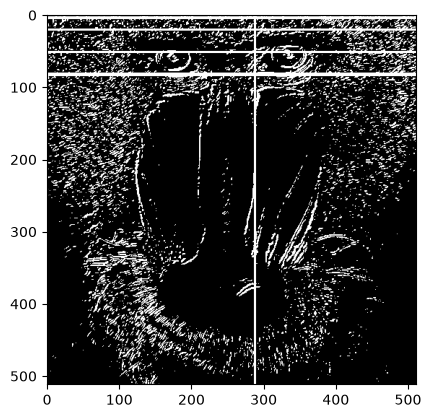

In [31]:
maxfil = np.max(sobel_cols)
umbral = 0.9 * maxfil

max_cols = np.where(sobel_cols >= umbral)[0]

print(f"Valor máximo (maxfil): {maxfil:.4f}")
print(f"Umbral (0.90 * maxfil): {umbral:.4f}")
print(f"Número de columnas que cumplen la condición: {len(max_cols)}")
print(f"Posiciones de dichas filas: {max_cols}")

print("--------------------------------------------------------------")

maxfil = np.max(sobel_rows)
umbral = 0.9 * maxfil

max_rows = np.where(sobel_rows >= umbral)[0]

print(f"Valor máximo (maxfil): {maxfil:.4f}")
print(f"Umbral (0.90 * maxfil): {umbral:.4f}")
print(f"Número de filas que cumplen la condición: {len(max_rows)}")
print(f"Posiciones de dichas filas: {max_rows}")

for row in max_rows:
    cv2.line(sobel8Umbral, (0, row), (sobel8Umbral.shape[1] - 1, row), 255, 1)

for col in max_cols:
    cv2.line(sobel8Umbral, (col, 0), (col, sobel8Umbral.shape[0] - 1), 255, 1)

plt.imshow(sobel8Umbral, cmap='gray') 